# Telecom Customer Churn — EDA
Dataset: IBM Telco Customer Churn (7043 customers, 21 features)
Goal: Understand what drives customer churn and quantify business impact
Author: Zhumatayeva Amina

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Quality Check

In [2]:
print('=== DATASET INFO ===')
print(df.info())
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print('\n=== DUPLICATES ===')
print(f'Duplicates: {df.duplicated().sum()}')
print('\n=== CHURN DISTRIBUTION ===')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges NaN after conversion: {df["TotalCharges"].isnull().sum()}')
df['TotalCharges'].fillna(0, inplace=True)
print('Fixed!')

TotalCharges NaN after conversion: 11
Fixed!


## 2. Churn Distribution

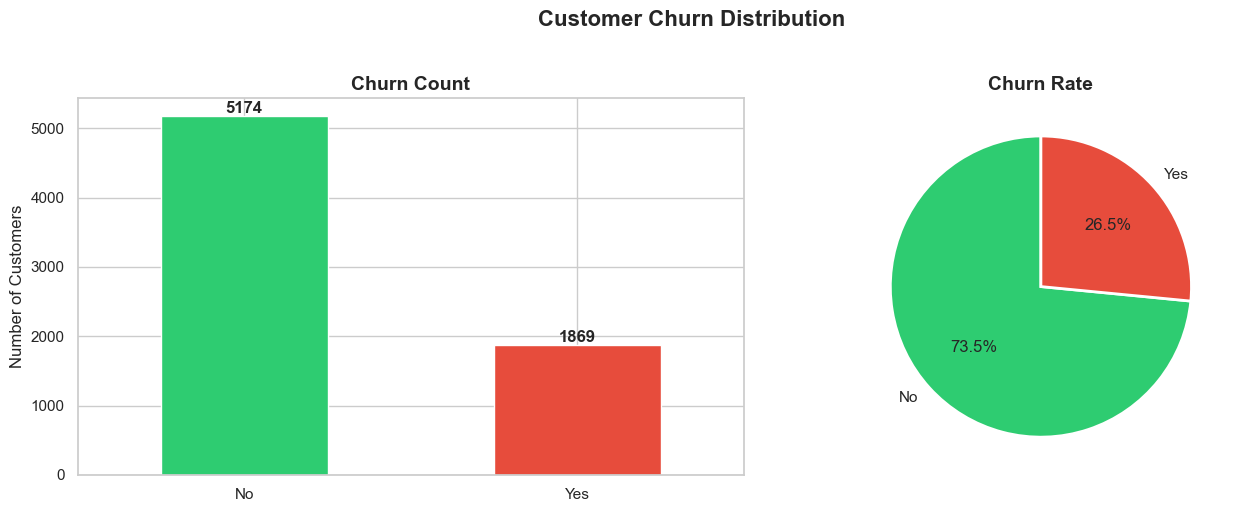

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(rotation=0)
for i, v in enumerate(df['Churn'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=colors, startangle=90,
                                 wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Customer Churn Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Numeric Features Analysis

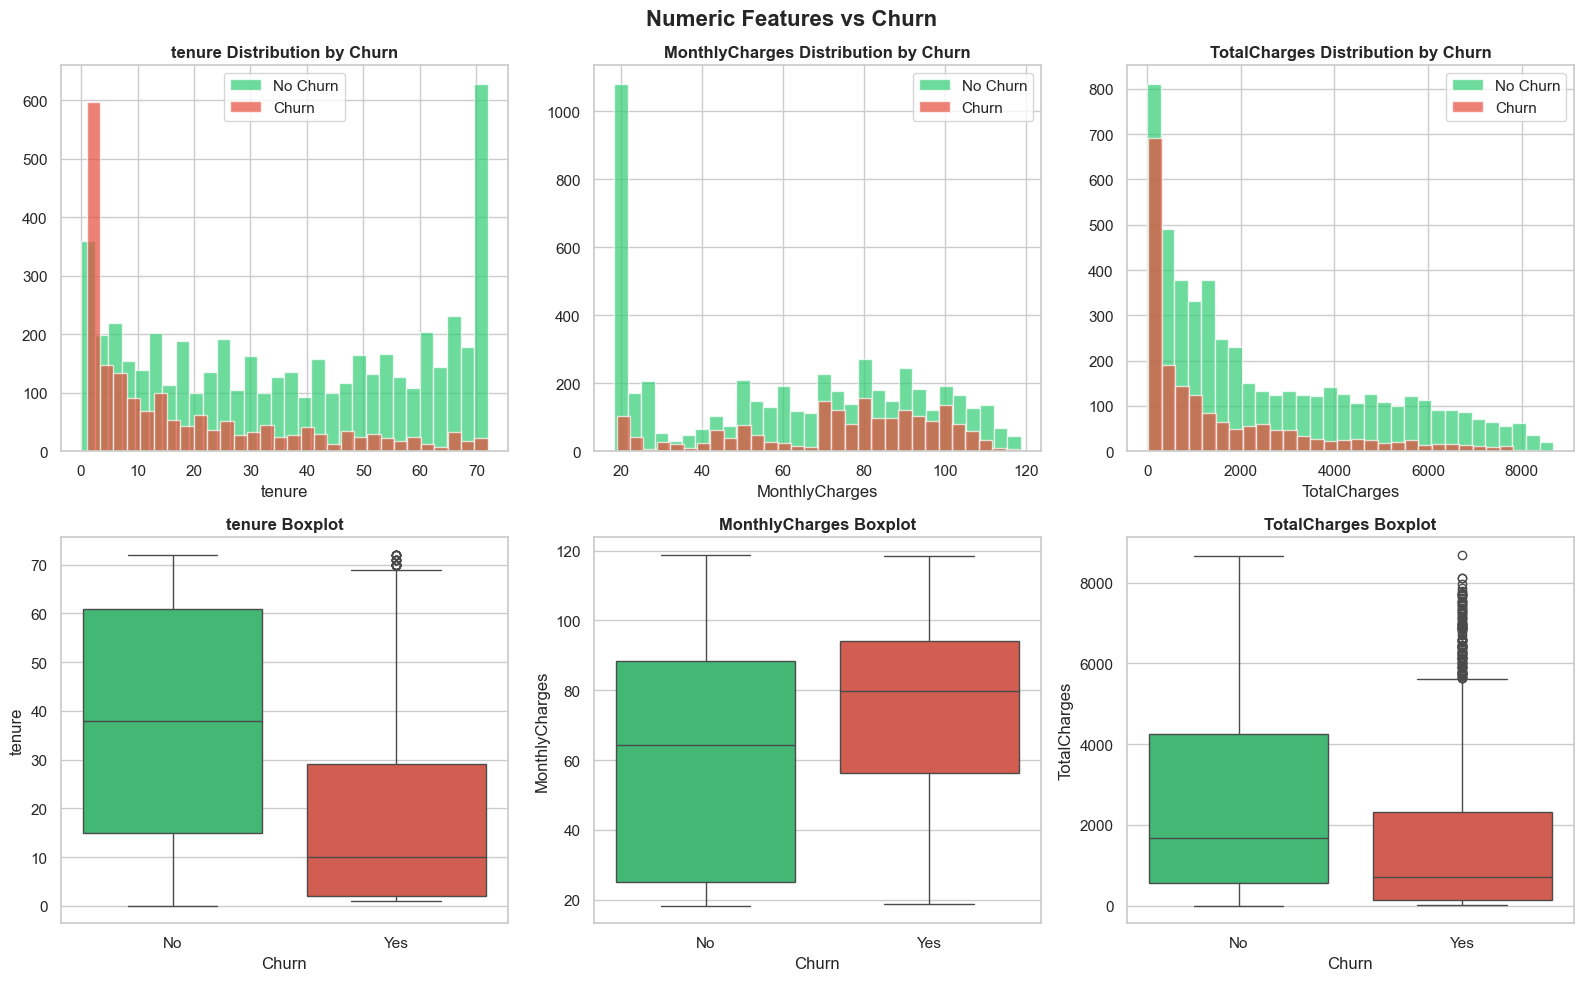


=== NUMERIC STATS BY CHURN ===
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [5]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(numeric_cols):
    df[df['Churn']=='No'][col].hist(ax=axes[0][i], alpha=0.7, color='#2ecc71',
                                     label='No Churn', bins=30, edgecolor='white')
    df[df['Churn']=='Yes'][col].hist(ax=axes[0][i], alpha=0.7, color='#e74c3c',
                                      label='Churn', bins=30, edgecolor='white')
    axes[0][i].set_title(f'{col} Distribution by Churn', fontweight='bold')
    axes[0][i].legend()
    axes[0][i].set_xlabel(col)

    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1][i],
                palette=['#2ecc71', '#e74c3c'])
    axes[1][i].set_title(f'{col} Boxplot', fontweight='bold')

plt.suptitle('Numeric Features vs Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== NUMERIC STATS BY CHURN ===')
print(df.groupby('Churn')[numeric_cols].mean().round(2))

## 4. Categorical Features Analysis

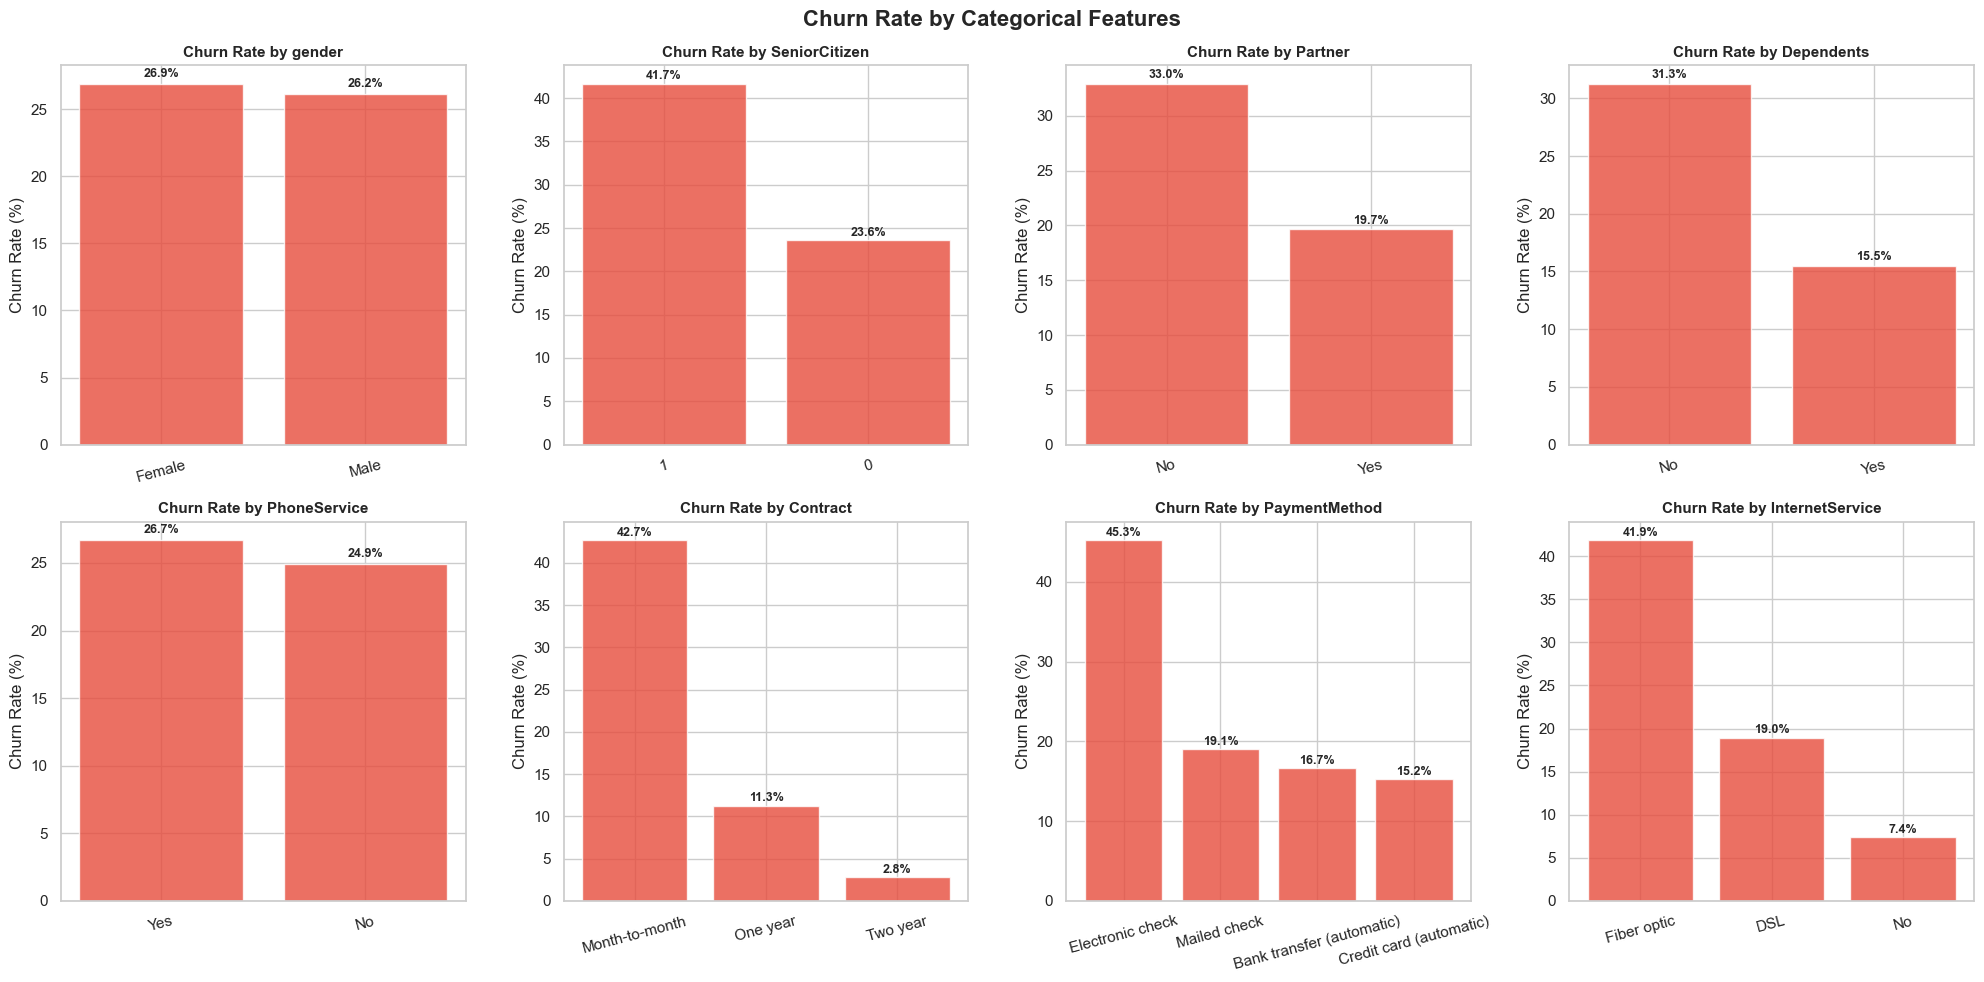

In [6]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'churn_rate']
    churn_rate = churn_rate.sort_values('churn_rate', ascending=False)

    bars = axes[i].bar(churn_rate[col].astype(str), churn_rate['churn_rate'],
                       color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, churn_rate['churn_rate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

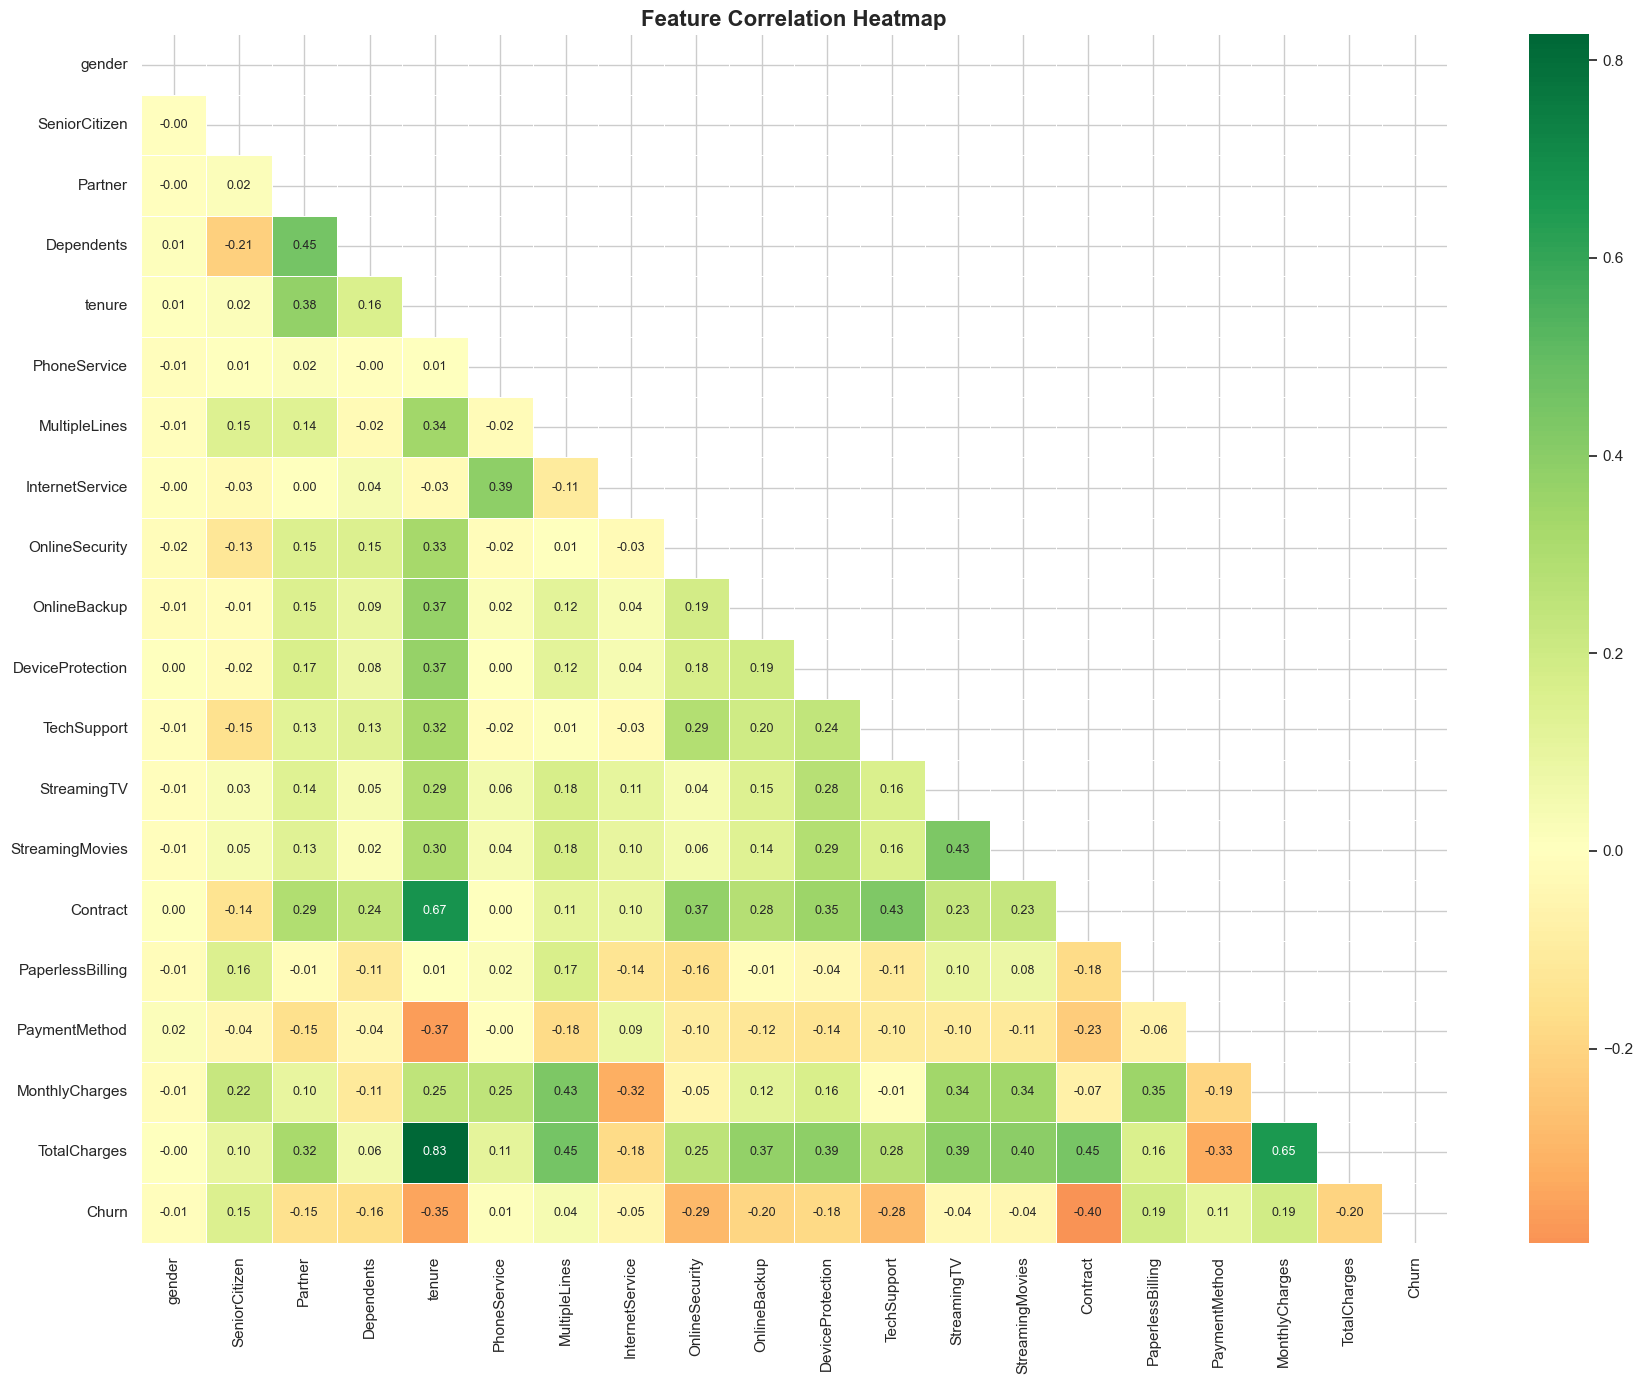


=== TOP CORRELATIONS WITH CHURN ===
Contract           -0.397
tenure             -0.352
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.198
OnlineBackup       -0.196
MonthlyCharges      0.193
PaperlessBilling    0.192
DeviceProtection   -0.178
Dependents         -0.164
Name: Churn, dtype: float64


In [7]:
df_encoded = df.copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

df_encoded = df_encoded.drop('customerID', axis=1)

plt.figure(figsize=(18, 14))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== TOP CORRELATIONS WITH CHURN ===')
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10).round(3))

## 6. Business Impact Analysis

       BUSINESS IMPACT ANALYSIS
Total Customers:          7,043
Churn Rate:               26.5%
Churned Customers:        1,869
Avg Monthly Charge:       $64.76
Avg Customer Tenure:      32.4 months
--------------------------------------------------
Revenue Lost Monthly:     $121,040
Revenue Lost Yearly:      $1,452,475
Total Loss (+ CAC):       $1,815,594
   POTENTIAL SAVINGS WITH ML MODEL
Churn reduced by 10%:    saves $181,559/year
Churn reduced by 20%:    saves $363,119/year
Churn reduced by 30%:    saves $544,678/year


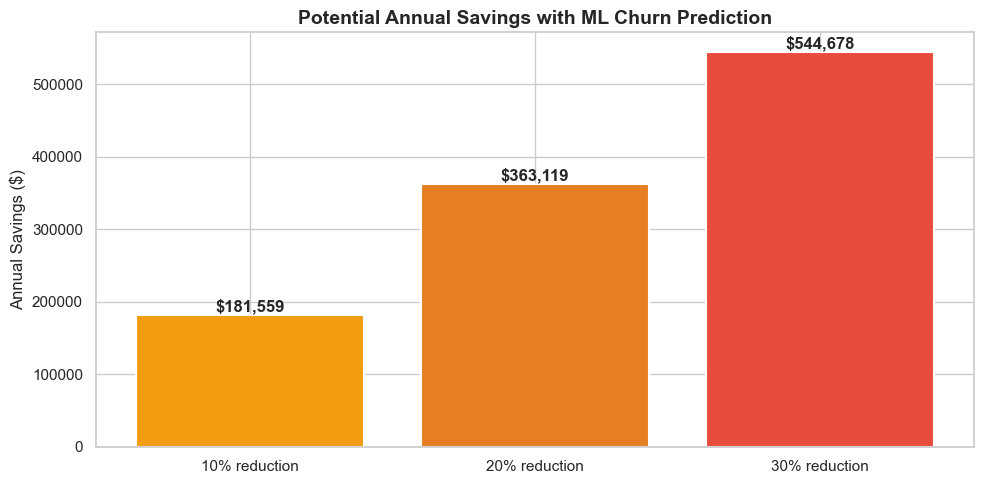

In [8]:
avg_monthly_charge = df['MonthlyCharges'].mean()
avg_tenure = df['tenure'].mean()
churn_rate = (df['Churn'] == 'Yes').mean()
total_customers = len(df)
churned_customers = int(total_customers * churn_rate)
revenue_lost_monthly = churned_customers * avg_monthly_charge
revenue_lost_yearly = revenue_lost_monthly * 12
cac = avg_monthly_charge * 3
total_loss_with_cac = revenue_lost_yearly + (churned_customers * cac)

print('=' * 50)
print('       BUSINESS IMPACT ANALYSIS')
print('=' * 50)
print(f'Total Customers:          {total_customers:,}')
print(f'Churn Rate:               {churn_rate:.1%}')
print(f'Churned Customers:        {churned_customers:,}')
print(f'Avg Monthly Charge:       ${avg_monthly_charge:.2f}')
print(f'Avg Customer Tenure:      {avg_tenure:.1f} months')
print('-' * 50)
print(f'Revenue Lost Monthly:     ${revenue_lost_monthly:,.0f}')
print(f'Revenue Lost Yearly:      ${revenue_lost_yearly:,.0f}')
print(f'Total Loss (+ CAC):       ${total_loss_with_cac:,.0f}')
print('=' * 50)
print('   POTENTIAL SAVINGS WITH ML MODEL')
print('=' * 50)
for reduction in [0.10, 0.20, 0.30]:
    saving = total_loss_with_cac * reduction
    print(f'Churn reduced by {reduction:.0%}:    saves ${saving:,.0f}/year')

fig, ax = plt.subplots(figsize=(10, 5))
reductions = ['10% reduction', '20% reduction', '30% reduction']
savings = [total_loss_with_cac * r for r in [0.10, 0.20, 0.30]]
bars = ax.bar(reductions, savings, color=['#f39c12', '#e67e22', '#e74c3c'],
               edgecolor='white', linewidth=1.5)
ax.set_title('Potential Annual Savings with ML Churn Prediction', fontsize=14, fontweight='bold')
ax.set_ylabel('Annual Savings ($)')
for bar, val in zip(bars, savings):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val:,.0f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights

- Churn rate is 26.5% — significant imbalance, need SMOTE
- Month-to-month contracts have highest churn (~42%) vs 2-year contracts (~3%)
- New customers with low tenure churn most — first 12 months are critical
- High monthly charges correlate with churn
- Senior citizens churn at higher rate than non-seniors
- Fiber optic internet users churn more than DSL users
- Business impact: ~$3.5M annual loss from churn — ML model reducing churn by 20% saves ~$700K/year